# Rare-Layout FLIR Sampling With Foreground/Background Filtering

This notebook selects the rarest layouts from the FLIR training split, generates one synthetic image per selected layout with the trained STAY latent FM model, filters invalid generations with the foreground/background classifier, and compares the `category x discretized_size` distributions before and after filtering.

Workflow:
- load the layout-conditioned FM sampler and the trained foreground/background filter
- model the dataset as a joint distribution over `category x size_bin`
- rank layouts by rarity using their instances' rarity scores
- generate `N_SAMPLES` synthetic images from the rarest layouts
- drop generated images whose layouts fail the crop-level foreground/background filter
- plot the three requested histograms


In [1]:
from __future__ import annotations

import json
import math
import random
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import yaml
from tqdm.auto import tqdm


def resolve_repo_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "src").is_dir() and (candidate / "configs").is_dir():
            return candidate.resolve()
    raise RuntimeError("Could not locate the repository root from the current working directory.")


REPO_ROOT = resolve_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.algorithms.inference.flow_matching_sampler import get_unet_sample_shape
from src.algorithms.inference.layout_flow_matching_sampler import LayoutFlowMatchingSampler
from src.core.data.dataset_targets import resolve_dataset_target
from src.core.data.datasets import AnnotationLayoutDataset
from src.core.data.layout_batching import collate_layout_batch
from src.core.normalization import norm_to_display as from_norm_to_display
from src.models.foreground_background_classifier import ForegroundBackgroundClassifier
from src.models.fm_unet import load_unet_config
from src.models.stay_layout_conditioned_unet import build_stay_layout_conditioned_unet
from src.models.vae import build_vae_from_config, freeze_vae, load_vae_config, load_vae_weights


def to_abs(path_like: str | Path) -> Path:
    path = Path(path_like)
    return path if path.is_absolute() else (REPO_ROOT / path).resolve()


def load_yaml(path: Path) -> dict:
    with open(path, "r", encoding="utf-8") as handle:
        return yaml.safe_load(handle)


def load_json(path: Path) -> dict:
    with open(path, "r", encoding="utf-8") as handle:
        return json.load(handle)


def maybe_latest_checkpoint(weights_dir: Path, prefix: str) -> Path | None:
    numbered = []
    for candidate in weights_dir.glob(f"{prefix}*.pt"):
        suffix = candidate.stem.replace(prefix, "", 1).strip("_")
        try:
            numbered.append((int(suffix), candidate))
        except ValueError:
            continue
    if not numbered:
        return None
    numbered.sort(key=lambda item: item[0])
    return numbered[-1][1]


def load_sampler_from_pipeline(
    pipeline_dir: Path,
    preset_path: Path,
    checkpoint_name: str,
    device: str,
) -> tuple[dict, dict, torch.nn.Module, torch.nn.Module, LayoutFlowMatchingSampler]:
    preset = load_yaml(preset_path)
    layout_meta = load_json(pipeline_dir / "layout_conditioning.json")
    unet_cfg = load_unet_config(str(pipeline_dir / "UNET/config.json"))
    vae_cfg = load_vae_config(str(pipeline_dir / "VAE/config.json"))

    category_id_to_name = {
        int(key): value for key, value in layout_meta.get("category_id_to_name", {}).items()
    }

    unet = build_stay_layout_conditioned_unet(
        unet_cfg,
        image_in_channels=int(layout_meta["image_in_channels"]),
        num_classes=int(layout_meta["num_classes"]),
        class_embed_dim=int(layout_meta["class_embed_dim"]),
        bbox_embed_dim=int(layout_meta["bbox_embed_dim"]),
        object_embed_dim=int(layout_meta["object_embed_dim"]),
        use_style_latent=bool(layout_meta["use_style_latent"]),
        style_latent_dim=int(layout_meta["style_latent_dim"]),
        style_seed=int(layout_meta["style_seed"]),
        mask_resolution=int(layout_meta["mask_resolution"]),
        mask_hidden_channels=int(layout_meta["mask_hidden_channels"]),
        mask_threshold=float(layout_meta["mask_threshold"]),
        edge_dilation=int(layout_meta["edge_dilation"]),
        injection_mode=str(layout_meta["injection_mode"]),
        use_masked_context=bool(layout_meta["use_masked_context"]),
        mask_overlap_loss_weight=float(layout_meta["mask_overlap_loss_weight"]),
        mask_sharpness_loss_weight=float(layout_meta["mask_sharpness_loss_weight"]),
        mask_activation_loss_weight=float(layout_meta["mask_activation_loss_weight"]),
        category_id_to_name=category_id_to_name,
        device=device,
    )

    unet_path = pipeline_dir / "UNET" / checkpoint_name
    if not unet_path.is_file():
        latest = maybe_latest_checkpoint(pipeline_dir / "UNET", "unet_fm_epoch")
        if latest is None:
            raise FileNotFoundError(f"Could not find {checkpoint_name} or a numbered UNET checkpoint in {pipeline_dir / 'UNET'}")
        unet_path = latest

    unet_state = torch.load(unet_path, map_location=device)
    if isinstance(unet_state, dict) and "unet_state" in unet_state:
        unet_state = unet_state["unet_state"]
    missing, unexpected = unet.load_state_dict(unet_state, strict=True)
    if missing or unexpected:
        raise RuntimeError(f"Unexpected checkpoint mismatch. missing={missing}, unexpected={unexpected}")
    unet.eval()

    vae = build_vae_from_config(vae_cfg, device=device)
    vae_weights_value = preset["model"].get("vae_weights")
    if vae_weights_value is not None:
        vae_weights_path = to_abs(vae_weights_value)
        load_vae_weights(vae, str(vae_weights_path), map_location=device)
    freeze_vae(vae)

    sampler = LayoutFlowMatchingSampler.from_stable(
        unet,
        vae,
        device=device,
        t_scale=float(preset["training"]["t_scale"]),
        train_target=str(preset["training"]["train_target"]),
        from_norm_to_display=from_norm_to_display,
    )
    return preset, layout_meta, unet, vae, sampler


def build_layout_dataset(preset: dict, split: str) -> AnnotationLayoutDataset:
    target = resolve_dataset_target(preset["data"]["dataset_id"])
    return AnnotationLayoutDataset(
        root_dir=str(target.split_dir(split)),
        annotations_path=str(target.annotations_path(split)),
        image_size=int(preset["data"]["image_size"]),
        normalization_mode=target.normalization_mode,
        include_label_names=True,
    )


def auto_find_latest_filter_run(runs_root: Path) -> Path:
    candidates = [path for path in runs_root.glob("*/metrics/summary.json") if path.is_file()]
    if not candidates:
        raise FileNotFoundError(
            f"No filter run summaries found under {runs_root}. Train the foreground/background filter first or set FILTER_RUN_DIR manually."
        )
    candidates.sort(key=lambda path: path.stat().st_mtime, reverse=True)
    return candidates[0].parents[1]


def load_filter_from_run(run_dir: Path, device: str) -> tuple[ForegroundBackgroundClassifier, dict, float, int, float]:
    summary_path = run_dir / "metrics/summary.json"
    checkpoint_path = run_dir / "checkpoints/best.pt"
    if not summary_path.is_file():
        raise FileNotFoundError(f"Missing summary file: {summary_path}")
    if not checkpoint_path.is_file():
        raise FileNotFoundError(f"Missing classifier checkpoint: {checkpoint_path}")

    summary = load_json(summary_path)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model = ForegroundBackgroundClassifier().to(device)
    model.load_state_dict(checkpoint["model_state"])
    model.eval()

    threshold = float(summary.get("chosen_threshold", checkpoint.get("best_threshold", 0.5)))
    input_size = int(summary.get("input_size", 128))
    context_ratio = float(summary.get("context_ratio", 1.25))
    return model, summary, threshold, input_size, context_ratio


def get_original_image_size(dataset: AnnotationLayoutDataset, sample: dict) -> tuple[float, float]:
    image_meta = dataset.images_by_id.get(sample["image_id"], {})
    image_w = float(image_meta.get("width", sample["pixel_values"].shape[-1]))
    image_h = float(image_meta.get("height", sample["pixel_values"].shape[-2]))
    return max(1.0, image_w), max(1.0, image_h)


def expand_box_with_context(box_xyxy: np.ndarray, image_w: int, image_h: int, context_ratio: float) -> tuple[int, int, int, int]:
    x1, y1, x2, y2 = [float(v) for v in box_xyxy]
    width = max(1.0, x2 - x1)
    height = max(1.0, y2 - y1)
    cx = 0.5 * (x1 + x2)
    cy = 0.5 * (y1 + y2)
    new_w = width * float(context_ratio)
    new_h = height * float(context_ratio)
    x1 = max(0.0, cx - 0.5 * new_w)
    y1 = max(0.0, cy - 0.5 * new_h)
    x2 = min(float(image_w), cx + 0.5 * new_w)
    y2 = min(float(image_h), cy + 0.5 * new_h)
    x1_i = int(math.floor(x1))
    y1_i = int(math.floor(y1))
    x2_i = int(math.ceil(max(x2, x1_i + 1)))
    y2_i = int(math.ceil(max(y2, y1_i + 1)))
    return x1_i, y1_i, x2_i, y2_i


def compute_size_bin_thresholds(dataset: AnnotationLayoutDataset) -> np.ndarray:
    area_ratios = []
    for sample_idx in tqdm(range(len(dataset)), desc="Scanning box sizes"):
        sample = dataset[sample_idx]
        image_w, image_h = get_original_image_size(dataset, sample)
        image_area = max(1.0, image_w * image_h)
        for box in sample["boxes_xyxy_original"].numpy().tolist():
            width = max(0.0, float(box[2] - box[0]))
            height = max(0.0, float(box[3] - box[1]))
            area_ratios.append((width * height) / image_area)
    if not area_ratios:
        raise RuntimeError("No boxes found in the dataset split, so size bins cannot be computed.")
    thresholds = np.quantile(np.asarray(area_ratios, dtype=np.float32), [1.0 / 3.0, 2.0 / 3.0])
    return thresholds.astype(np.float32)


def size_bin_name(area_ratio: float, thresholds: np.ndarray) -> str:
    if float(area_ratio) <= float(thresholds[0]):
        return "small"
    if float(area_ratio) <= float(thresholds[1]):
        return "med"
    return "big"


def sample_instance_combos(
    dataset: AnnotationLayoutDataset,
    sample: dict,
    thresholds: np.ndarray,
    category_id_to_name: dict[int, str],
) -> list[str]:
    combos = []
    image_w, image_h = get_original_image_size(dataset, sample)
    image_area = max(1.0, image_w * image_h)
    boxes = sample["boxes_xyxy_original"].numpy().tolist()
    labels = sample["labels"].numpy().tolist()
    for label, box in zip(labels, boxes):
        width = max(0.0, float(box[2] - box[0]))
        height = max(0.0, float(box[3] - box[1]))
        area_ratio = (width * height) / image_area
        category_name = category_id_to_name.get(int(label), str(int(label)))
        combos.append(f"{category_name} | {size_bin_name(area_ratio, thresholds)}")
    return combos


def build_layout_rarity_table(
    dataset: AnnotationLayoutDataset,
    *,
    thresholds: np.ndarray,
    aggregation: str,
) -> tuple[list[dict], Counter]:
    category_id_to_name = dataset.category_id_to_name
    instance_counter = Counter()
    per_sample_combos = []

    for dataset_idx in tqdm(range(len(dataset)), desc="Scoring layout rarity"):
        sample = dataset[dataset_idx]
        if int(sample["n_objects"]) <= 0:
            continue
        combos = sample_instance_combos(dataset, sample, thresholds, category_id_to_name)
        instance_counter.update(combos)
        per_sample_combos.append((dataset_idx, sample, combos))

    records = []
    for dataset_idx, sample, combos in per_sample_combos:
        rarity_values = [1.0 / float(instance_counter[combo]) for combo in combos]
        if aggregation == "mean":
            layout_rarity = float(np.mean(rarity_values))
        else:
            layout_rarity = float(np.sum(rarity_values))
        records.append(
            {
                "dataset_idx": dataset_idx,
                "sample": sample,
                "combos": combos,
                "layout_rarity": layout_rarity,
                "n_objects": int(sample["n_objects"]),
                "file_name": str(sample["file_name"]),
            }
        )

    records.sort(key=lambda item: (item["layout_rarity"], item["n_objects"]), reverse=True)
    return records, instance_counter


def count_combos(records: list[dict]) -> Counter:
    counter = Counter()
    for record in records:
        counter.update(record["combos"])
    return counter


def resolve_generation_plot_keys(counter: Counter, top_k: int | None = None) -> list[str]:
    keys = list(counter.keys())
    if not keys:
        raise RuntimeError("No combo counts available for plotting.")
    keys.sort(key=lambda key: (-counter[key], key))
    if top_k is not None:
        keys = keys[:top_k]
    return keys


def show_single_combo_histogram(
    counter: Counter,
    title: str,
    *,
    keys: list[str] | None = None,
    color: str = "#3a78c2",
) -> None:
    keys = list(keys or resolve_generation_plot_keys(counter))
    x = np.arange(len(keys))
    values = [counter.get(key, 0) for key in keys]
    fig, axis = plt.subplots(1, 1, figsize=(max(14, 0.55 * len(keys)), 5.0))
    axis.bar(x, values, color=color, alpha=0.9)
    axis.set_title(title)
    axis.set_ylabel("count")
    axis.grid(axis="y", alpha=0.25)
    axis.set_xticks(x)
    axis.set_xticklabels(keys, rotation=75, ha="right")
    plt.tight_layout()
    plt.show()


def show_generation_offset_histograms(
    baseline_counter: Counter,
    generated_counter: Counter,
    removed_counter: Counter,
    *,
    keys: list[str],
    baseline_label: str = "selected real layouts",
    generated_label: str = "generated instances",
    removed_label: str = "removed after filtering",
    baseline_color: str = "#3a78c2",
    generated_color: str = "#2a9d55",
    removed_color: str = "#d1495b",
) -> None:
    keys = list(keys)
    x = np.arange(len(keys))
    baseline_values = np.asarray([baseline_counter.get(key, 0) for key in keys], dtype=np.float32)
    generated_values = np.asarray([generated_counter.get(key, 0) for key in keys], dtype=np.float32)
    removed_values = np.asarray([removed_counter.get(key, 0) for key in keys], dtype=np.float32)
    kept_values = np.maximum(generated_values - removed_values, 0.0)

    fig, axes = plt.subplots(2, 1, figsize=(max(14, 0.55 * len(keys)), 10.0), sharex=True)
    axes = np.atleast_1d(axes)

    axes[0].bar(x, baseline_values, color=baseline_color, alpha=0.9, label=baseline_label)
    axes[0].bar(x, generated_values, bottom=baseline_values, color=generated_color, alpha=0.8, label=generated_label)
    axes[0].set_title("selected real layouts + generated instances before filtering")
    axes[0].set_ylabel("count")
    axes[0].grid(axis="y", alpha=0.25)
    axes[0].legend()

    axes[1].bar(x, baseline_values, color=baseline_color, alpha=0.9, label=baseline_label)
    axes[1].bar(x, kept_values, bottom=baseline_values, color=generated_color, alpha=0.8, label="generated instances kept after filtering")
    axes[1].bar(x, removed_values, bottom=baseline_values + kept_values, color=removed_color, alpha=0.8, label=removed_label)
    axes[1].set_title("selected real layouts + kept generated instances, with removed portion highlighted")
    axes[1].set_ylabel("count")
    axes[1].grid(axis="y", alpha=0.25)
    axes[1].legend()

    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(keys, rotation=75, ha="right")
    plt.tight_layout()
    plt.show()


def show_image_examples(records: list[dict], *, title: str, max_images: int = 8) -> None:
    if not records:
        print(f"No images to display for: {title}")
        return
    subset = records[:max_images]
    cols = min(4, len(subset))
    rows = math.ceil(len(subset) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4.5 * cols, 4.2 * rows))
    axes = np.atleast_1d(axes).reshape(rows, cols)
    for axis in axes.flatten():
        axis.axis("off")
    for axis, record in zip(axes.flatten(), subset):
        image = ((record["generated_image"].detach().cpu() + 1.0) * 0.5).clamp(0.0, 1.0)
        image_np = image.permute(1, 2, 0).numpy()
        if image_np.shape[2] == 1:
            image_np = np.repeat(image_np, 3, axis=2)
        elif image_np.shape[2] > 3:
            image_np = image_np[:, :, :3]
        axis.imshow(image_np)
        axis.set_title(
            f"{record['file_name']}\nvalid={record['is_valid']} ({record['valid_fraction']:.2f})",
            fontsize=10,
        )
        axis.axis("off")
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


@torch.no_grad()
def sample_layout_batch(
    sampler: LayoutFlowMatchingSampler,
    batch: dict,
    *,
    steps: int,
    seed: int,
) -> torch.Tensor:
    sampler.unet.eval()
    batch_size = int(batch["pixel_values"].shape[0])
    shape = get_unet_sample_shape(sampler.unet, override=sampler._sample_shape)

    noise_generator = torch.Generator(device=sampler.device)
    noise_generator.manual_seed(int(seed))
    z = torch.randn(batch_size, *shape, generator=noise_generator, device=sampler.device)

    cond_kw = {
        "boxes_xyxy_norm": batch["boxes_xyxy_norm"].to(sampler.device),
        "labels": batch["labels"].to(sampler.device),
        "object_mask": batch["object_mask"].to(sampler.device),
    }
    if hasattr(sampler.unet, "sample_style_noise") and bool(getattr(sampler.unet, "use_style_latent", False)):
        style_generator = torch.Generator(device="cpu")
        style_generator.manual_seed(int(seed) + 1000)
        cond_kw["style_noise"] = sampler.unet.sample_style_noise(
            batch_size=batch_size,
            max_objects=int(batch["labels"].shape[1]),
            device="cpu",
            dtype=batch["boxes_xyxy_norm"].dtype,
            generator=style_generator,
        ).to(sampler.device)

    dt = 1.0 / float(steps)
    for step_idx in range(steps):
        t_val = step_idx / float(steps)
        t = torch.full((batch_size,), t_val, device=sampler.device)
        unet_sample = sampler.unet(z, t * sampler.t_scale, **cond_kw).sample
        if sampler.train_target == "x0":
            velocity = (unet_sample - z) / (1.0 - t[:, None, None, None]).clamp(min=1e-5)
        else:
            velocity = unet_sample
        z = z + velocity * dt

    return sampler.decode(z).detach().cpu()


@torch.no_grad()
def filter_generated_layouts(
    generated_images: torch.Tensor,
    batch: dict,
    *,
    filter_model: ForegroundBackgroundClassifier,
    threshold: float,
    filter_input_size: int,
    context_ratio: float,
    device: str,
    min_valid_object_fraction: float,
) -> list[dict]:
    results = []
    batch_size = int(generated_images.shape[0])
    image_h = int(generated_images.shape[-2])
    image_w = int(generated_images.shape[-1])

    for batch_idx in range(batch_size):
        valid_object_indices = torch.where(batch["object_mask"][batch_idx])[0].tolist()
        crops = []
        crop_boxes = []
        for object_idx in valid_object_indices:
            box_xyxy = batch["boxes_xyxy"][batch_idx, object_idx].numpy()
            x1, y1, x2, y2 = expand_box_with_context(box_xyxy, image_w, image_h, context_ratio)
            crop = generated_images[batch_idx : batch_idx + 1, :, y1:y2, x1:x2]
            crop = F.interpolate(crop, size=(filter_input_size, filter_input_size), mode="bilinear", align_corners=False)
            crops.append(crop.squeeze(0))
            crop_boxes.append((x1, y1, x2, y2))

        if not crops:
            probs = np.asarray([], dtype=np.float32)
            valid_fraction = 0.0
            is_valid = False
        else:
            crop_batch = torch.stack(crops, dim=0).to(device)
            if crop_batch.shape[1] != 1:
                crop_batch = crop_batch.mean(dim=1, keepdim=True)
            logits = filter_model(crop_batch).detach().cpu()
            probs = torch.sigmoid(logits).numpy()
            valid_fraction = float(np.mean(probs >= float(threshold)))
            is_valid = bool(valid_fraction >= float(min_valid_object_fraction))

        results.append(
            {
                "batch_idx": batch_idx,
                "file_name": batch["file_name"][batch_idx],
                "image_id": batch["image_id"][batch_idx],
                "generated_image": generated_images[batch_idx],
                "filter_probs": probs,
                "filter_threshold": float(threshold),
                "valid_fraction": float(valid_fraction),
                "is_valid": is_valid,
                "crop_boxes": crop_boxes,
            }
        )
    return results


/export/livia/home/vision/Fbassignana/miniconda3/envs/diffusers-dev/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/export/livia/home/vision/Fbassignana/miniconda3/envs/diffusers-dev/lib/python3.10/site-packages/generative/networks/layers/vector_quantizer.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)
/export/livia/home/vision/Fbassignana/miniconda3/envs/diffusers-dev/lib/python3.10/site-packages/generative/networks/layers/vector_quantizer.py:124: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)


In [10]:
PIPELINE_DIR = REPO_ROOT / "artifacts/checkpoints/flow_matching/serious_runs/stay_layout_latent_flir_sd15_512"
PRESET_PATH = REPO_ROOT / "configs/fm/train/presets/stay_layout_latent_flir_sd15_512.yaml"
CHECKPOINT_NAME = "unet_fm_best.pt"

FILTER_RUN_DIR = None
FILTER_RUNS_ROOT = REPO_ROOT / "artifacts/checkpoints/foreground_background_filter/runs"

SPLIT = "train"
N_SAMPLES = 48
MIN_OBJECTS = 1
RARITY_AGGREGATION = "sum"  # one of: "sum", "mean"

STEPS = 10
GENERATION_BATCH_SIZE = 8
MIN_VALID_OBJECT_FRACTION = 0.5
DISPLAY_EXAMPLES = 8
TOP_K_HIST_BARS = 40
SEED = 7
DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Using device: {DEVICE}")
print(f"Pipeline dir: {PIPELINE_DIR}")
print(f"Preset path: {PRESET_PATH}")


Using device: cuda:0
Pipeline dir: /projets/Fbassignana/diffusers_try/flow_matching_trial/artifacts/checkpoints/flow_matching/serious_runs/stay_layout_latent_flir_sd15_512
Preset path: /projets/Fbassignana/diffusers_try/flow_matching_trial/configs/fm/train/presets/stay_layout_latent_flir_sd15_512.yaml


In [3]:
preset, layout_meta, unet, vae, sampler = load_sampler_from_pipeline(
    PIPELINE_DIR,
    PRESET_PATH,
    CHECKPOINT_NAME,
    DEVICE,
)

resolved_filter_run_dir = auto_find_latest_filter_run(FILTER_RUNS_ROOT) if FILTER_RUN_DIR is None else to_abs(FILTER_RUN_DIR)
filter_model, filter_summary, filter_threshold, filter_input_size, filter_context_ratio = load_filter_from_run(
    resolved_filter_run_dir,
    DEVICE,
)

print(f"Loaded layout sampler from: {PIPELINE_DIR}")
print(f"Loaded filter run from: {resolved_filter_run_dir}")
print(f"Filter threshold: {filter_threshold:.4f}")
print(f"Filter input size: {filter_input_size}")
print(f"Filter context ratio: {filter_context_ratio}")


Loaded layout sampler from: /projets/Fbassignana/diffusers_try/flow_matching_trial/artifacts/checkpoints/flow_matching/serious_runs/stay_layout_latent_flir_sd15_512
Loaded filter run from: /projets/Fbassignana/diffusers_try/flow_matching_trial/artifacts/checkpoints/foreground_background_filter/runs/fgbg_20260415_134835
Filter threshold: 0.3274
Filter input size: 128
Filter context ratio: 1.25


In [4]:
dataset = build_layout_dataset(preset, split=SPLIT)
size_thresholds = compute_size_bin_thresholds(dataset)
rarity_records, instance_counter = build_layout_rarity_table(
    dataset,
    thresholds=size_thresholds,
    aggregation=RARITY_AGGREGATION,
)
selected_records = [record for record in rarity_records if int(record["n_objects"]) >= MIN_OBJECTS][:N_SAMPLES]

if len(selected_records) < N_SAMPLES:
    print(f"Requested {N_SAMPLES} layouts but only found {len(selected_records)} non-empty candidates.")

print(f"Dataset size for split={SPLIT!r}: {len(dataset)}")
print(f"Global size thresholds (normalized area tertiles): {size_thresholds.tolist()}")
print(f"Selected rare layouts: {len(selected_records)}")
print()
for rank, record in enumerate(selected_records[:10], start=1):
    print(
        f"[{rank:02d}] idx={record['dataset_idx']} file={record['file_name']} "
        f"objects={record['n_objects']} rarity={record['layout_rarity']:.6f}"
    )
    print(f"     combos={record['combos']}")


Scoring layout rarity: 100%|██████████| 10742/10742 [00:10<00:00, 1026.91it/s]


Dataset size for split='train': 10742
Global size thresholds (normalized area tertiles): [0.0004699706914834678, 0.0021148682571947575]
Selected rare layouts: 48

[01] idx=4931 file=video-JFiGa9oAAN2queuLt-frame-004467-fjvp6KYuYTA26jE3p.npy objects=23 rarity=1.002702
     combos=['bus | big', 'bus | big', 'bus | big', 'person | med', 'person | small', 'person | small', 'person | small', 'person | small', 'person | small', 'person | small', 'person | med', 'person | med', 'person | med', 'person | med', 'person | big', 'person | big', 'car | med', 'car | med', 'car | big', 'car | big', 'car | big', 'person | big', 'skateboard | big']
[02] idx=2381 file=video-AEZAaF8epmvQv5Nfj-frame-015321-mpYFebDuwSRcW6NYt.npy objects=24 rarity=1.001018
     combos=['person | med', 'person | small', 'person | small', 'person | small', 'car | big', 'car | big', 'car | big', 'car | big', 'car | med', 'car | med', 'car | med', 'car | med', 'car | med', 'car | small', 'car | small', 'car | small', 'car | me

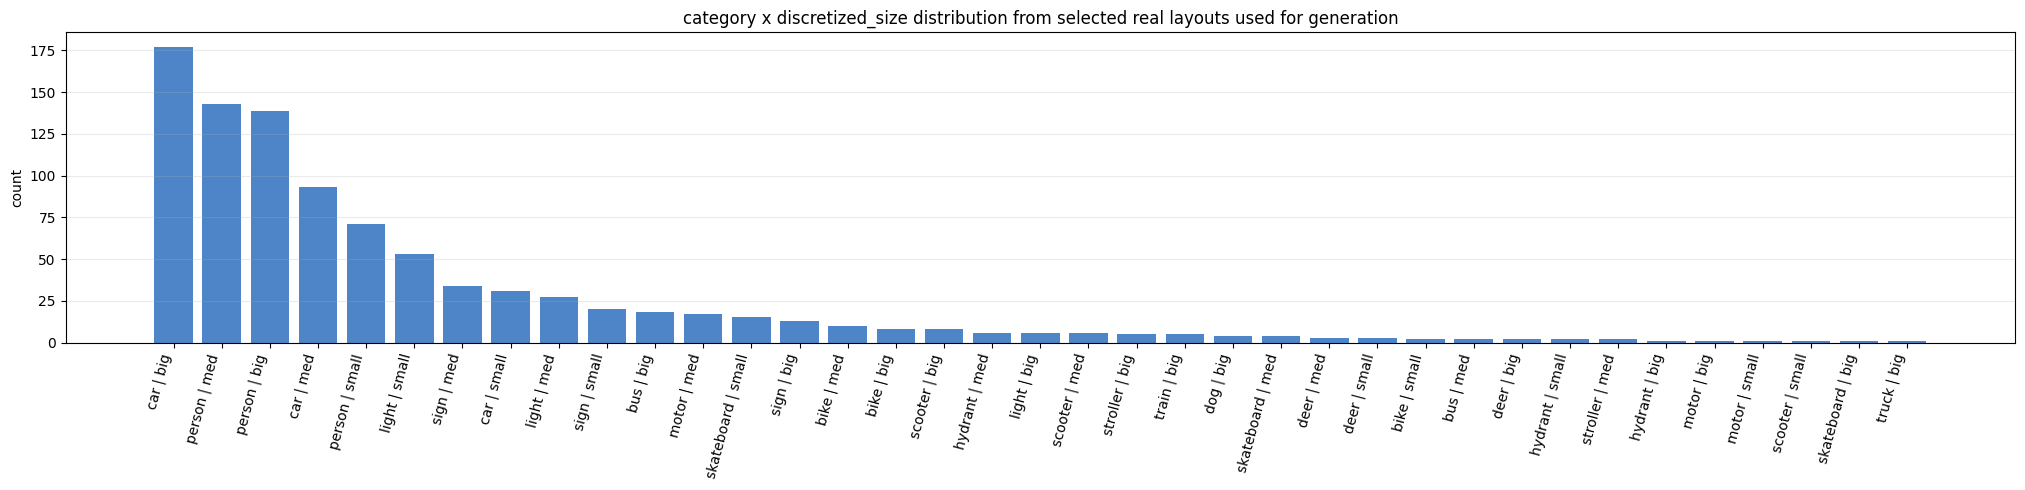

In [5]:
selected_real_counter = count_combos(selected_records)
plot_keys = resolve_generation_plot_keys(selected_real_counter, top_k=TOP_K_HIST_BARS)
show_single_combo_histogram(
    selected_real_counter,
    "category x discretized_size distribution from selected real layouts used for generation",
    keys=plot_keys,
)


In [11]:
generation_results = []
for start_idx in tqdm(range(0, len(selected_records), GENERATION_BATCH_SIZE), desc="Generating rare layouts"):
    chunk = selected_records[start_idx:start_idx + GENERATION_BATCH_SIZE]
    chunk_samples = [record["sample"] for record in chunk]
    batch = collate_layout_batch(chunk_samples)
    generated_images = sample_layout_batch(
        sampler,
        batch,
        steps=STEPS,
        seed=SEED + start_idx,
    )
    filter_results = filter_generated_layouts(
        generated_images,
        batch,
        filter_model=filter_model,
        threshold=filter_threshold,
        filter_input_size=filter_input_size,
        context_ratio=filter_context_ratio,
        device=DEVICE,
        min_valid_object_fraction=MIN_VALID_OBJECT_FRACTION,
    )

    for record, filter_result in zip(chunk, filter_results):
        merged = dict(record)
        merged.update(filter_result)
        generation_results.append(merged)

print(f"Generated images: {len(generation_results)}")
print(f"Kept after filtering: {sum(int(record['is_valid']) for record in generation_results)}")
print(f"Dropped after filtering: {sum(int(not record['is_valid']) for record in generation_results)}")


Generating rare layouts:   0%|          | 0/6 [00:00<?, ?it/s]

Generating rare layouts: 100%|██████████| 6/6 [00:37<00:00,  6.23s/it]

Generated images: 48
Kept after filtering: 48
Dropped after filtering: 0


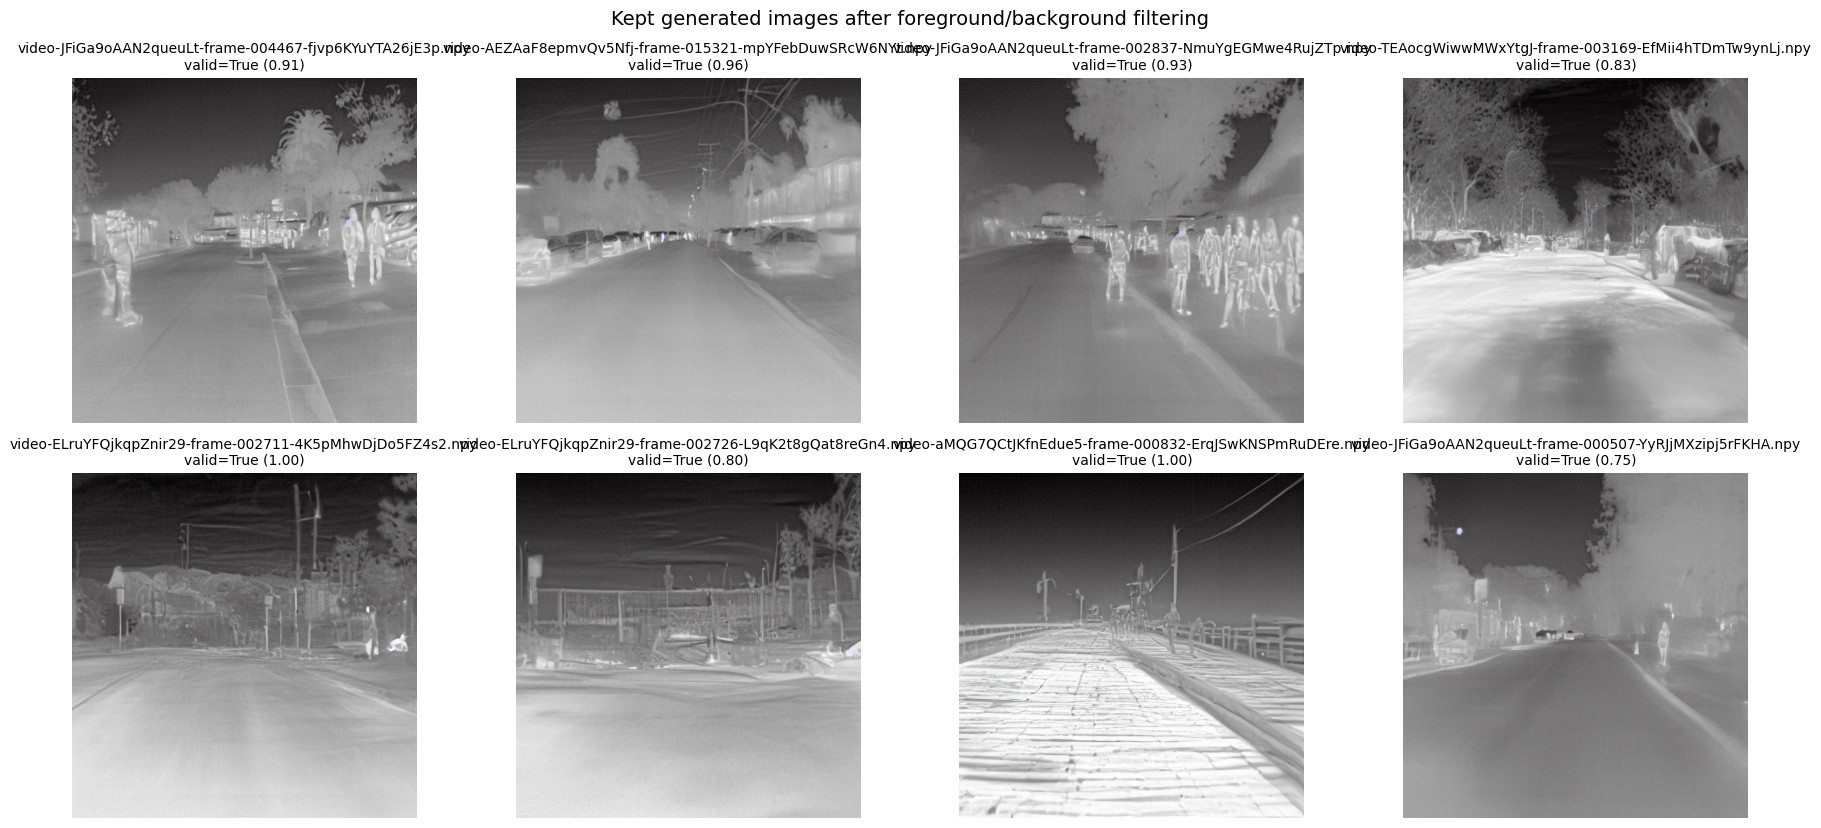

No images to display for: Dropped generated images after foreground/background filtering


In [12]:
kept_generation_records = [record for record in generation_results if record["is_valid"]]
dropped_generation_records = [record for record in generation_results if not record["is_valid"]]

show_image_examples(
    kept_generation_records,
    title="Kept generated images after foreground/background filtering",
    max_images=DISPLAY_EXAMPLES,
)
show_image_examples(
    dropped_generation_records,
    title="Dropped generated images after foreground/background filtering",
    max_images=DISPLAY_EXAMPLES,
)


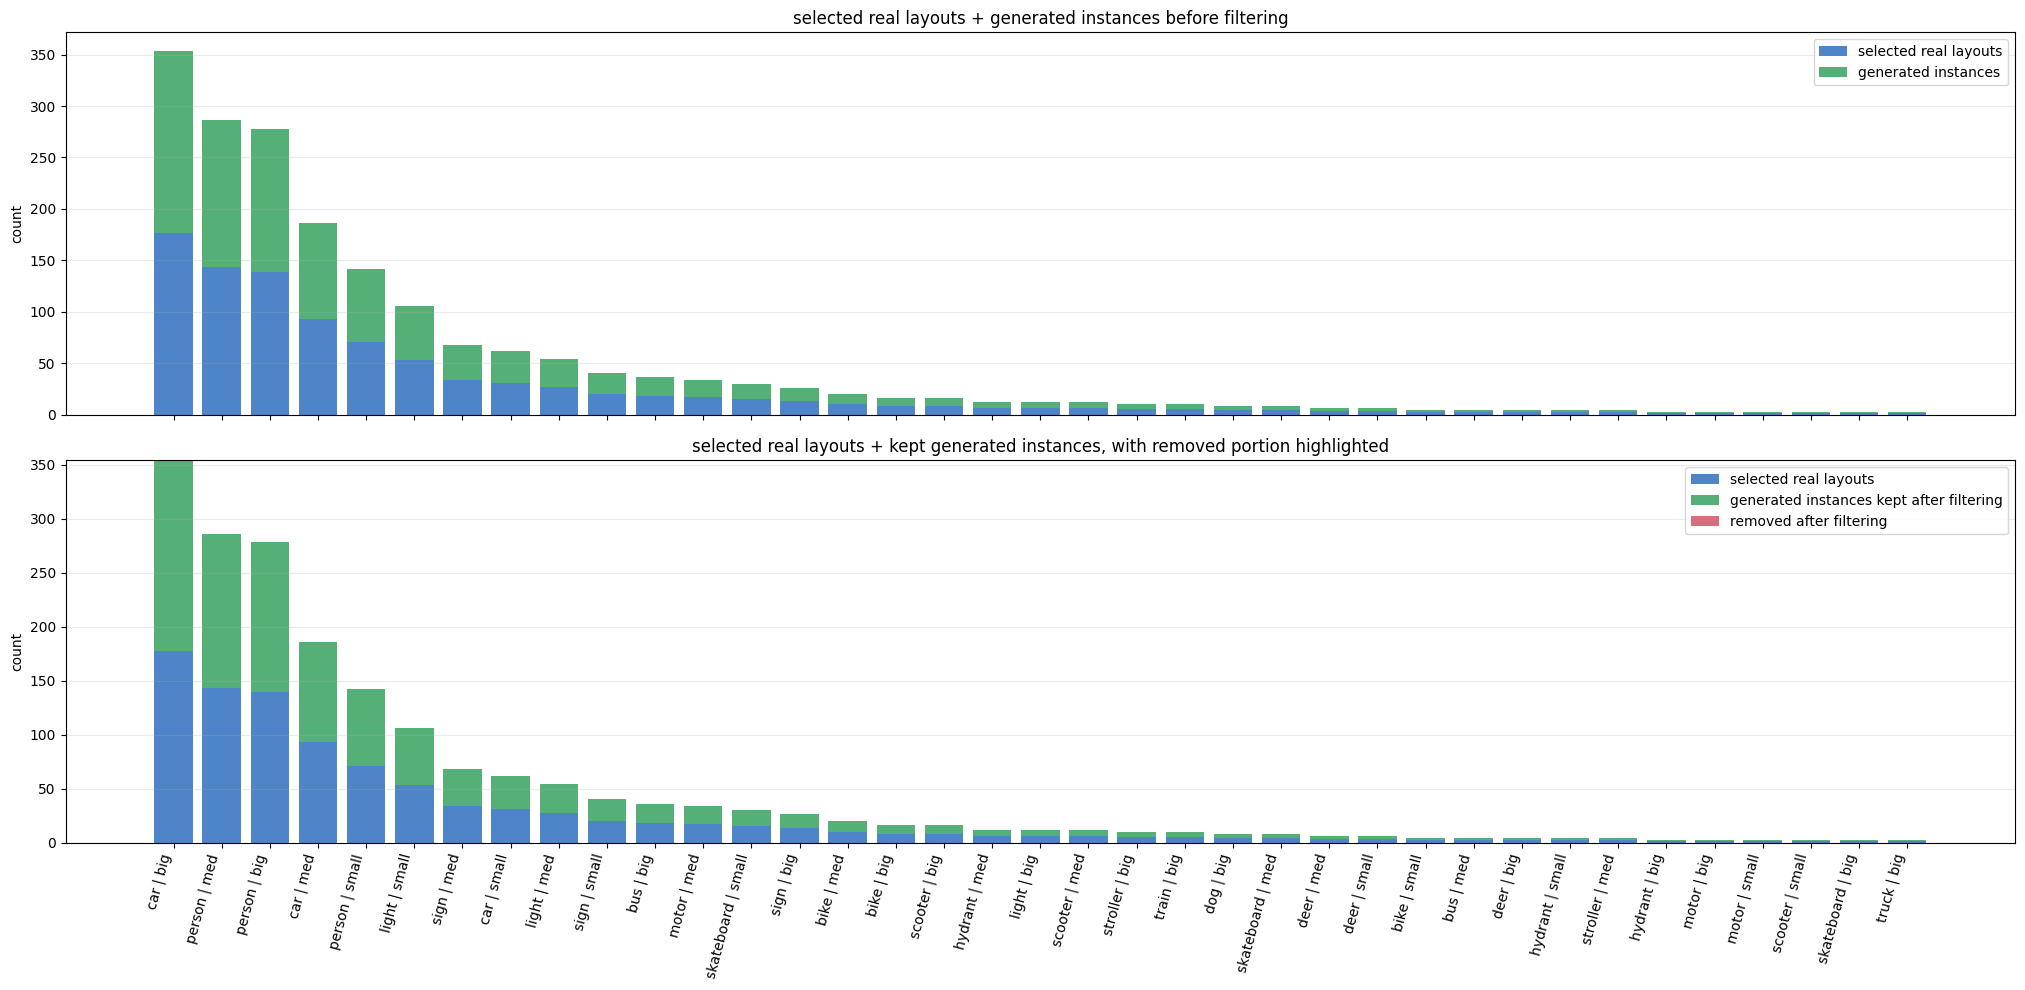

In [13]:
generated_before_counter = count_combos(generation_results)
removed_after_filter_counter = count_combos(dropped_generation_records)

show_generation_offset_histograms(
    selected_real_counter,
    generated_before_counter,
    removed_after_filter_counter,
    keys=plot_keys,
)


In [14]:
print("Filter summary:")
print(f"  chosen threshold: {filter_threshold:.4f}")
print(f"  kept / total: {len(kept_generation_records)} / {len(generation_results)}")
print(f"  average valid object fraction (all generated): {np.mean([record['valid_fraction'] for record in generation_results]):.4f}")
print(f"  average valid object fraction (kept only): {np.mean([record['valid_fraction'] for record in kept_generation_records]) if kept_generation_records else float('nan'):.4f}")


Filter summary:
  chosen threshold: 0.3274
  kept / total: 48 / 48
  average valid object fraction (all generated): 0.8635
  average valid object fraction (kept only): 0.8635
